/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

24BAD128-EXP 8-Scenario 1
Dataset Preview:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Sample Transactions:
[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]

Encoded Data:
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             

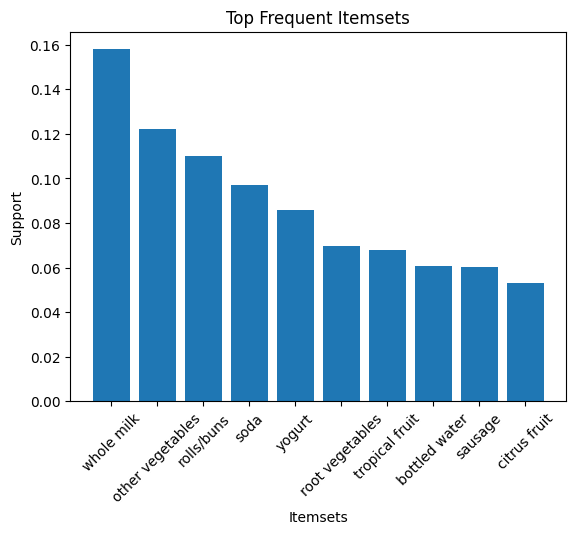

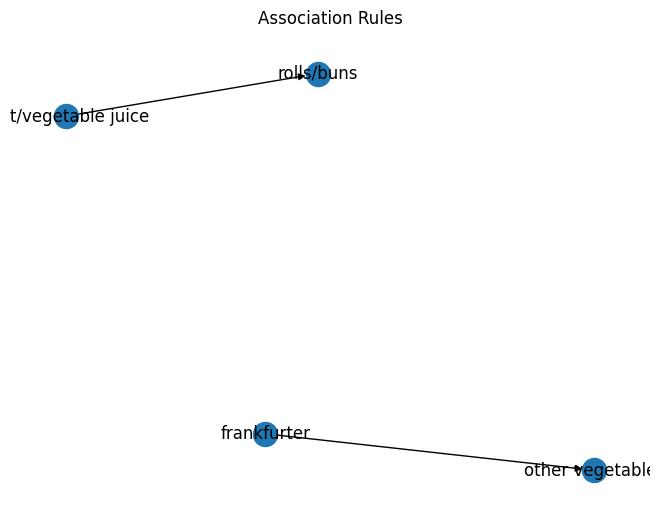

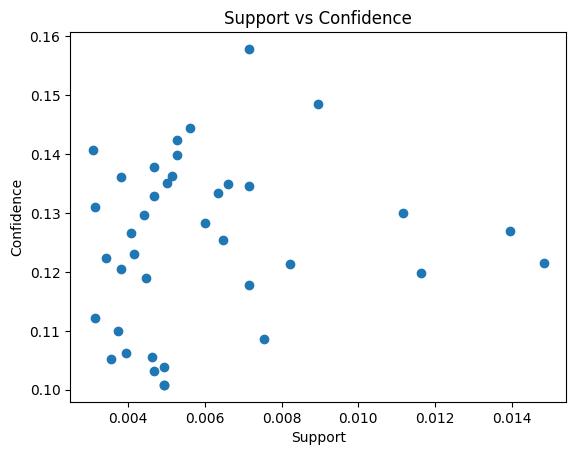

In [4]:
#24BAD128-EXP 8-Scenario 1
#from google.colab import files
#uploaded = files.upload()

import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx

print("24BAD128-EXP 8-Scenario 1")

# Load Dataset
df = pd.read_csv("Groceries_dataset.csv")

print("Dataset Preview:")
print(df.head())


# Data Preprocessing
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)
transactions = list(transactions)

print("\nSample Transactions:")
print(transactions[:5])


# One-Hot Encoding
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_data, columns=te.columns_)

print("\nEncoded Data:")
print(df_encoded.head())


# Frequent Itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.003, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets.head())


# Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
print("\nNumber of Rules:", len(rules))

print("\nRules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


# Strong Rules
strong_rules = rules[(rules['confidence'] > 0.03) & (rules['lift'] > 1)]

print("\nStrong Rules:")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Bar Chart
top = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
labels = [', '.join(list(i)) for i in top['itemsets']]

plt.figure()
plt.bar(labels, top['support'])
plt.xticks(rotation=45)
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.title("Top Frequent Itemsets")
plt.show()

# Network Graph
G = nx.DiGraph()

for _, row in strong_rules.iterrows():
    a = ', '.join(list(row['antecedents']))
    b = ', '.join(list(row['consequents']))
    G.add_edge(a, b)

plt.figure()
nx.draw(G, with_labels=True)
plt.title("Association Rules")
plt.show()

# Support vs Confidence
if len(rules) > 0:
    plt.scatter(rules['support'], rules['confidence'])
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.title("Support vs Confidence")
    plt.show()
else:
    print("No rules to display")

24BAD128-EXP 8-Scenario 2
Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


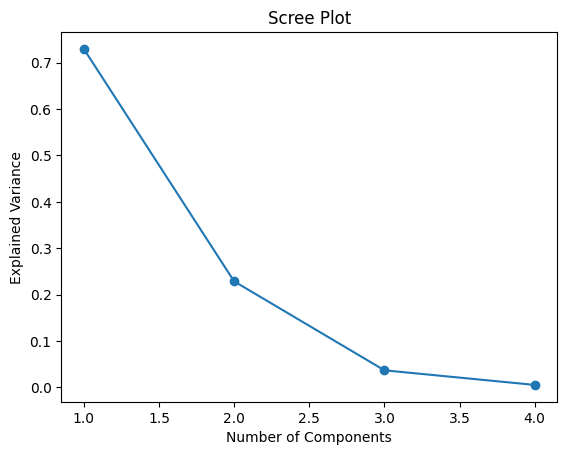

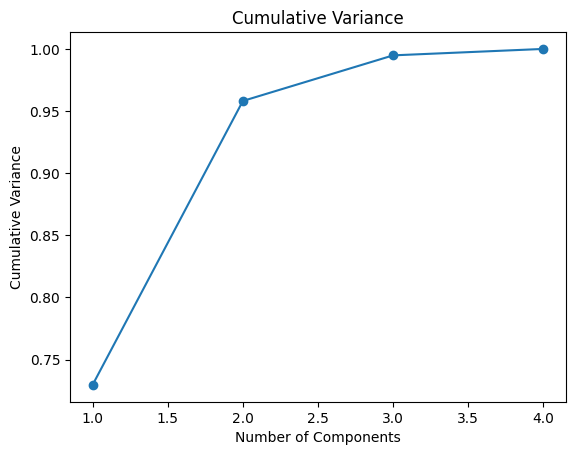

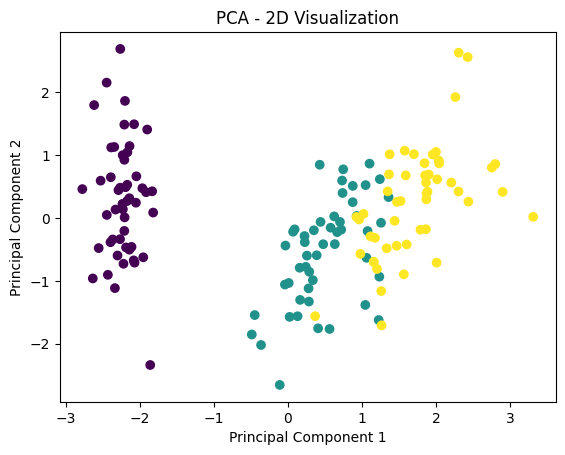

In [7]:
#24BAD128-EXP 8-Scenario 2
#from google.colab import files
#uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("24BAD128-EXP 8-Scenario 2")

# 1. Load Dataset
iris = load_iris()
df = pd.read_csv("IRIS.csv")

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

print("Dataset Preview:")
print(df.head())


# 2. Check Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# 3. Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
print(explained_variance)

# 6. Cumulative Variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Variance:")
print(cumulative_variance)

# 7. Reduce to 2 Components
pca2 = PCA(n_components=2)
X_reduced = pca2.fit_transform(X_scaled)

# 8. Scree Plot
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

# 9. Cumulative Variance Plot
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance")
plt.show()

# 10. 2D Scatter Plot
plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Visualization")
plt.show()